# Soft Targets, Temperature, and Dark Knowledge

**Goal:** build intuition for *why* knowledge distillation works, using nothing
but a hand-crafted teacher logit vector. No training, no GPU -- pure numpy and
matplotlib.

In distillation (Hinton, Vinyals & Dean, 2015), a small *student* network is
trained to mimic the output *distribution* of a large *teacher* network, rather
than just the correct hard label. The key insight is that a teacher's full
probability vector carries far more information than a one-hot label.

Consider a 6-class image classifier over
`['cat', 'dog', 'car', 'truck', 'plane', 'ship']`. Suppose the true label of an
image is `dog`. A one-hot label says only: *this is a dog, and it is equally
not-any-of the other five*. But a good teacher will say something richer: *this
is very probably a dog; if forced to pick a runner-up, `cat` is far more
plausible than `car` or `plane`.*

That relative structure among the wrong answers -- `cat > car ~ plane` -- is
what Hinton calls **dark knowledge**. It encodes the teacher's learned notion
of similarity (cats and dogs are both furry animals; cars and planes are
vehicles). A one-hot label throws all of it away.

## Setup

We seed numpy for reproducibility (`np.random.seed(0)`) and hand-craft a
teacher logit vector. The teacher is **confident on `dog`**, but among the
non-target classes it assigns **meaningfully more mass to `cat`** than to the
vehicle classes. Those non-target ratios are the dark knowledge we want to
expose.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

classes = ['cat', 'dog', 'car', 'truck', 'plane', 'ship']

# Hand-crafted teacher logits.
# Index 1 ('dog') is the confident winner. Among the rest, 'cat' (index 0)
# carries clearly more mass than the vehicles -- that is the dark knowledge.
#                 cat   dog   car  truck  plane  ship
teacher_logits = np.array([6.0, 9.0, 3.0,  2.5,   1.0,  1.5])

target_idx = 1  # 'dog' is the ground-truth label

for name, logit in zip(classes, teacher_logits):
    print(f'{name:>6}: logit = {logit:.1f}')

   cat: logit = 6.0
   dog: logit = 9.0
   car: logit = 3.0
 truck: logit = 2.5
 plane: logit = 1.0
  ship: logit = 1.5


## 1. Softmax with temperature

The standard softmax converts logits `z` into probabilities:

$$ p_i = \frac{\exp(z_i)}{\sum_j \exp(z_j)} $$

Distillation adds a **temperature** `T` that divides the logits before the
exponential:

$$ p_i(T) = \frac{\exp(z_i / T)}{\sum_j \exp(z_j / T)} $$

- `T = 1` is the ordinary softmax: the winner dominates, non-target
  probabilities are squashed toward zero and their relative structure is
  nearly invisible.
- As `T` grows the distribution gets **softer** (flatter). The gaps between
  logits shrink in the exponent, so the small differences among non-target
  classes get amplified into visible probability mass.
- As `T -> infinity` the distribution approaches uniform (`1/K` for every
  class).

Raising the temperature is how we *turn up the volume* on the dark knowledge
so the student can hear it. We implement a numerically stable softmax
(subtract the max before exponentiating) and plot the teacher's softened
distribution at `T` in `{1, 2, 4, 8}`.

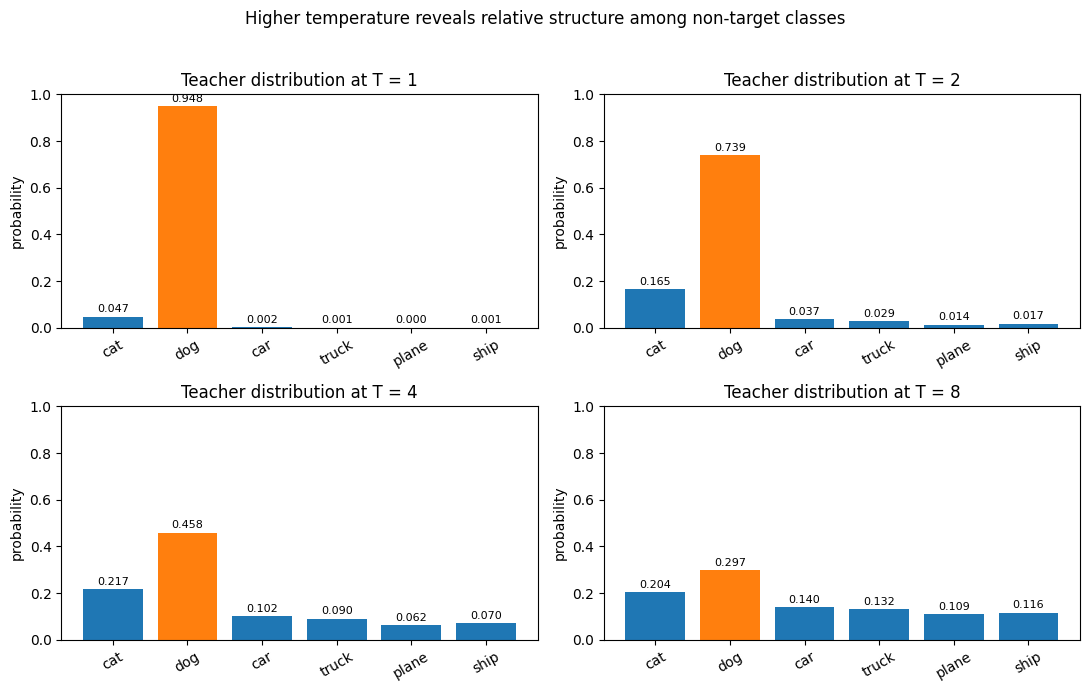

In [2]:
def softmax_with_temperature(logits, T=1.0):
    """Numerically stable temperature-scaled softmax."""
    scaled = np.asarray(logits, dtype=float) / T
    scaled = scaled - np.max(scaled)  # stability: avoids overflow in exp
    exp = np.exp(scaled)
    return exp / np.sum(exp)


temperatures = [1, 2, 4, 8]

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
axes = axes.ravel()
x = np.arange(len(classes))

for ax, T in zip(axes, temperatures):
    probs = softmax_with_temperature(teacher_logits, T=T)
    colors = ['tab:orange' if i == target_idx else 'tab:blue'
              for i in range(len(classes))]
    bars = ax.bar(x, probs, color=colors)
    ax.set_title(f'Teacher distribution at T = {T}')
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=30)
    ax.set_ylabel('probability')
    ax.set_ylim(0, 1.0)
    for rect, p in zip(bars, probs):
        ax.text(rect.get_x() + rect.get_width() / 2, p + 0.01,
                f'{p:.3f}', ha='center', va='bottom', fontsize=8)

fig.suptitle('Higher temperature reveals relative structure among '
             'non-target classes', fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Read the panels left-to-right.** At `T = 1` the `dog` bar (orange) towers
over everything and the five non-target bars are nearly flat against the
floor -- you cannot tell `cat` apart from `plane` by eye. As `T` climbs to 8,
the distribution flattens and the *ordering* among the wrong answers becomes
obvious: `cat` clearly carries more mass than `car`, `truck`, `plane`, `ship`.

Crucially, raising `T` does **not** change the *ranking* (dog is still on top,
cat is still the runner-up); it only changes how *visible* the lower-order
structure is. That structure is the teacher's learned similarity metric, and
it is exactly what we want the student to absorb.

Let us print the numbers to make the dark-knowledge ratio concrete.

In [3]:
print('Non-target probability mass at each temperature')
print('(notice how cat / plane ratio stays > 1 but becomes easier to learn '
      'as T grows)\n')
header = 'T'.rjust(3) + ''.join(c.rjust(9) for c in classes)
print(header)
for T in temperatures:
    probs = softmax_with_temperature(teacher_logits, T=T)
    row = str(T).rjust(3) + ''.join(f'{p:9.4f}' for p in probs)
    print(row)

p1 = softmax_with_temperature(teacher_logits, T=1)
p8 = softmax_with_temperature(teacher_logits, T=8)
print(f'\ncat/plane probability ratio  at T=1: {p1[0] / p1[4]:.2f}')
print(f'cat/plane probability ratio  at T=8: {p8[0] / p8[4]:.2f}')
print('The teacher *always* prefers cat over plane among non-targets;')
print('high T just makes that preference contribute more to the loss.')

Non-target probability mass at each temperature
(notice how cat / plane ratio stays > 1 but becomes easier to learn as T grows)

  T      cat      dog      car    truck    plane     ship
  1   0.0472   0.9482   0.0024   0.0014   0.0003   0.0005
  2   0.1649   0.7388   0.0368   0.0286   0.0135   0.0174
  4   0.2166   0.4585   0.1023   0.0903   0.0620   0.0703
  8   0.2044   0.2974   0.1405   0.1320   0.1094   0.1164

cat/plane probability ratio  at T=1: 148.41
cat/plane probability ratio  at T=8: 1.87
The teacher *always* prefers cat over plane among non-targets;
high T just makes that preference contribute more to the loss.


## 2. What the distillation loss optimizes

Now bring in a **student**. The student also produces logits; we soften them
at the same temperature `T` and compare against the teacher's softened
distribution. The *distillation* term of the loss is the
**KL divergence** of the teacher (soft target) from the student:

$$ \mathrm{KL}(p^T_{teacher} \,\|\, p^T_{student}) = \sum_i p^T_{teacher,i} \, \log \frac{p^T_{teacher,i}}{p^T_{student,i}} $$

Minimizing this pulls the student's *entire softened distribution* toward the
teacher's -- including the non-target structure (the dark knowledge).

Contrast that with the conventional **hard-label cross-entropy**, computed at
`T = 1` against the one-hot ground truth:

$$ \mathrm{CE}(\text{one-hot}, p^{T=1}_{student}) = -\log p^{T=1}_{student,\,\text{target}} $$

Hard-label CE only cares about the probability assigned to `dog`; it is
completely indifferent to how the remaining mass is distributed. We will
compute both for two students -- one whose mistakes echo the teacher's
similarity structure, and one whose mistakes do not -- to see what each loss
rewards.

In [4]:
def kl_divergence(p, q, eps=1e-12):
    """KL(p || q): expected extra surprise of using q when truth is p."""
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    return float(np.sum(p * np.log((p + eps) / (q + eps))))


def hard_cross_entropy(probs, target_idx, eps=1e-12):
    """Cross-entropy against the one-hot hard label = -log p[target]."""
    return float(-np.log(probs[target_idx] + eps))


# Student A: agrees on 'dog' AND echoes the teacher's dark knowledge
# (its second-favorite is also 'cat').
#                  cat   dog   car  truck  plane  ship
student_A_logits = np.array([5.0, 8.0, 2.5,  2.0,   1.2,  1.4])

# Student B: also predicts 'dog' correctly with similar confidence,
# but its non-target structure is WRONG -- it thinks 'plane' is the
# runner-up, not 'cat'. Hard CE will barely notice; KL will punish it.
#                  cat   dog   car  truck  plane  ship
student_B_logits = np.array([1.2, 8.0, 2.0,  2.5,   5.0,  1.4])

print('Student A logits:', student_A_logits)
print('Student B logits:', student_B_logits)

Student A logits: [5.  8.  2.5 2.  1.2 1.4]
Student B logits: [1.2 8.  2.  2.5 5.  1.4]


In [5]:
T = 4  # distillation temperature

teacher_T = softmax_with_temperature(teacher_logits, T=T)
A_T = softmax_with_temperature(student_A_logits, T=T)
B_T = softmax_with_temperature(student_B_logits, T=T)

# Hard-label cross-entropy is always measured at T = 1.
A_hard = softmax_with_temperature(student_A_logits, T=1)
B_hard = softmax_with_temperature(student_B_logits, T=1)

kl_A = kl_divergence(teacher_T, A_T)
kl_B = kl_divergence(teacher_T, B_T)
ce_A = hard_cross_entropy(A_hard, target_idx)
ce_B = hard_cross_entropy(B_hard, target_idx)

print(f'Distillation temperature T = {T}\n')
print(f"{'metric':<34}{'Student A':>12}{'Student B':>12}")
print('-' * 58)
print(f"{'KL(teacher_T || student_T)':<34}{kl_A:>12.4f}{kl_B:>12.4f}")
print(f"{'hard cross-entropy vs one-hot':<34}{ce_A:>12.4f}{ce_B:>12.4f}")
print()
print('Both students predict the correct hard label (dog) about equally well,')
print('so their hard cross-entropy is nearly identical.')
print('But Student B mis-ranks the non-target classes, so its KL to the')
print('teacher is much larger -- the distillation loss penalizes exactly the')
print('dark-knowledge mistake that the hard label is blind to.')

Distillation temperature T = 4

metric                               Student A   Student B
----------------------------------------------------------
KL(teacher_T || student_T)              0.0046      0.1529
hard cross-entropy vs one-hot           0.0572      0.0572

Both students predict the correct hard label (dog) about equally well,
so their hard cross-entropy is nearly identical.
But Student B mis-ranks the non-target classes, so its KL to the
teacher is much larger -- the distillation loss penalizes exactly the
dark-knowledge mistake that the hard label is blind to.


### Visualize: teacher vs the two students at T = 4

The bar chart below overlays the teacher's softened target with each student.
Watch the non-target bars: Student A tracks the teacher's `cat`-heavy
structure, while Student B piles mass on `plane`. The hard label cannot see
this difference; the KL term can.

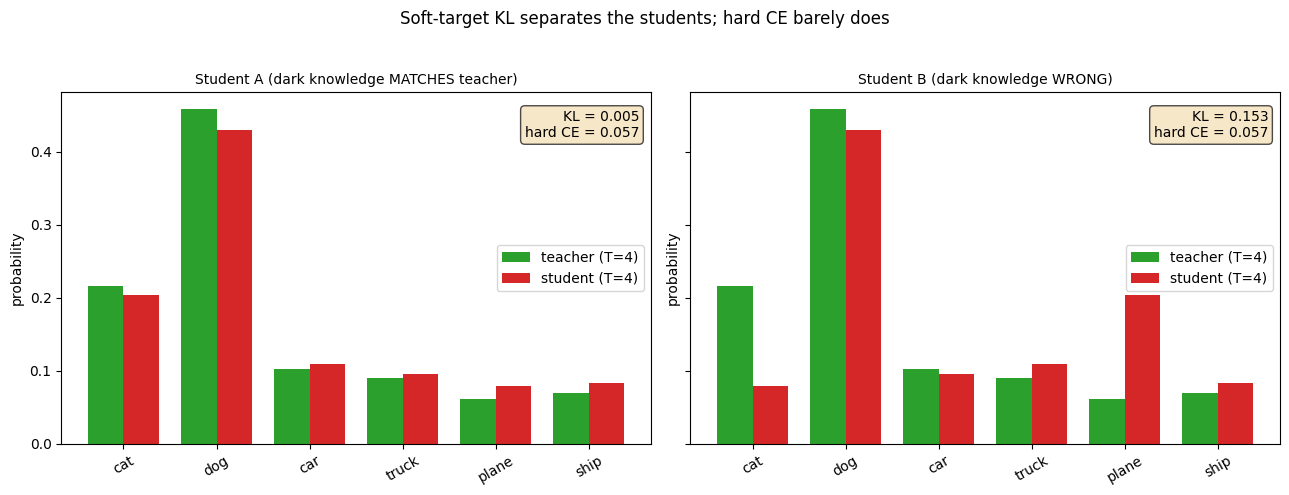

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
x = np.arange(len(classes))
width = 0.38

panels = [
    ('Student A (dark knowledge MATCHES teacher)', A_T, kl_A, ce_A),
    ('Student B (dark knowledge WRONG)', B_T, kl_B, ce_B),
]

for ax, (title, student_T, kl_val, ce_val) in zip(axes, panels):
    ax.bar(x - width / 2, teacher_T, width, label='teacher (T=4)',
           color='tab:green')
    ax.bar(x + width / 2, student_T, width, label='student (T=4)',
           color='tab:red')
    ax.set_title(title, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(classes, rotation=30)
    ax.set_ylabel('probability')
    ax.legend()
    ax.text(0.98, 0.95,
            f'KL = {kl_val:.3f}\nhard CE = {ce_val:.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

fig.suptitle('Soft-target KL separates the students; hard CE barely does',
             fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 3. Why the T-squared factor?

In practice the distillation loss is a weighted sum of the soft-target term
and the hard-label term:

$$ \mathcal{L} = \alpha \, T^2 \cdot \mathrm{KL}\!\left(p^T_{teacher} \,\|\, p^T_{student}\right) + (1 - \alpha) \cdot \mathrm{CE}\!\left(\text{one-hot}, p^{T=1}_{student}\right) $$

The curious part is the **`T^2` multiplier** on the soft-target term. It is
there to keep the *gradient magnitudes* of the two terms on the same scale so
that one hyperparameter (`alpha`) can balance them regardless of the chosen
temperature.

**Where it comes from.** Consider the gradient of the soft loss with respect
to a student logit `z_i`. With temperature scaling, the student probability
is `softmax(z_i / T)`. The factor of `1/T` inside the softmax flows through
the chain rule, and the gradient of the KL (or equivalently the soft
cross-entropy) with respect to `z_i` looks like

$$ \frac{\partial}{\partial z_i} \approx \frac{1}{T}\left(p^T_{student,i} - p^T_{teacher,i}\right). $$

When the logits are large compared to `T`, a first-order expansion shows the
*difference in parentheses* itself scales like `1/T`, so the whole soft-target
gradient scales roughly as `1/T^2`. Multiplying the soft loss by `T^2` cancels
that shrinkage, restoring its gradient to the same order of magnitude as the
hard-label term (whose gradient is `O(1)` because it is evaluated at `T = 1`).

**Why it matters.** Without the `T^2` factor, raising the temperature would
silently *down-weight* the soft term: at `T = 8` the distillation signal would
be ~64x weaker than at `T = 1`, and you would have to re-tune `alpha` every
time you changed `T`. The `T^2` factor decouples the two knobs. Let us
demonstrate the `1/T^2` scaling numerically.

In [7]:
# Empirical check of the 1/T^2 gradient scaling.
# We measure the magnitude of the (student - teacher) soft-probability gap
# divided by T -- a proxy for the per-logit soft-target gradient -- and show
# that multiplying by T^2 keeps it roughly flat across temperatures.
print(f"{'T':>3}{'raw grad proxy':>18}{'x T^2 (rescaled)':>20}")
print('-' * 41)
for T in [1, 2, 4, 8, 16]:
    teach = softmax_with_temperature(teacher_logits, T=T)
    stud = softmax_with_temperature(student_A_logits, T=T)
    # per-logit soft gradient magnitude ~ (1/T) * ||p_student - p_teacher||
    raw = (1.0 / T) * np.sum(np.abs(stud - teach))
    rescaled = (T ** 2) * raw
    print(f'{T:>3}{raw:>18.5f}{rescaled:>20.5f}')

print()
print('The raw gradient proxy collapses toward zero as T grows (~1/T^2),')
print('while the T^2-rescaled column stays on a comparable scale -- which is')
print('exactly why the T^2 factor is needed to balance against the hard term.')

  T    raw grad proxy    x T^2 (rescaled)
-----------------------------------------
  1           0.00784             0.00784
  2           0.03441             0.13763
  4           0.02063             0.33004
  8           0.00588             0.37600
 16           0.00144             0.36904

The raw gradient proxy collapses toward zero as T grows (~1/T^2),
while the T^2-rescaled column stays on a comparable scale -- which is
exactly why the T^2 factor is needed to balance against the hard term.


## Takeaways

1. **A one-hot label is information-poor.** It states the answer and nothing
   about the relationships between classes.
2. **A teacher's softened distribution is information-rich.** The relative
   probabilities among the *wrong* answers (dark knowledge) encode a learned
   similarity structure -- `cat ~ dog`, `car ~ truck ~ plane ~ ship`.
3. **Temperature is a magnifying glass.** Higher `T` flattens the
   distribution so the small non-target probabilities -- and their ordering --
   become large enough to provide a useful training signal.
4. **The distillation loss (KL on soft targets) optimizes the whole
   distribution**, so it rewards a student for getting the dark knowledge
   right -- something plain hard-label cross-entropy is blind to.
5. **The `T^2` factor** rescales the soft-target gradient (which shrinks like
   `1/T^2`) so a single `alpha` balances the soft and hard terms across any
   temperature.

*Reference: Hinton, Vinyals & Dean, "Distilling the Knowledge in a Neural
Network" (2015), arXiv:1503.02531.*